In [1]:
from tqdm import tqdm
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import pickle as pkl
from Bio.Seq import Seq
from scipy.stats import spearmanr

tqdm.pandas()

data_dir = '/scratch/users/milind_jagota/bcr/data/heavylight/trees/'
indels_dir = "/accounts/projects/yss/stephen.lu/protevo/plmr/data/wyatt/raw/"

## Load and preprocess trees

In [2]:
heavy = pd.read_csv(data_dir + 'wyatt-10x-1p5m_paired-igh_fs-all_pcp_2024-11-21.csv.gz', compression='gzip', index_col=0)
kappa = pd.read_csv(data_dir + 'wyatt-10x-1p5m_paired-igk_fs-all_pcp_2024-11-21.csv.gz', compression='gzip', index_col=0)
lambd = pd.read_csv(data_dir + 'wyatt-10x-1p5m_paired-igl_fs-all_pcp_2024-11-21.csv.gz', compression='gzip', index_col=0)
indels = pd.read_csv(indels_dir + "wyatt-10x-1p5m_fs-all-prank_paired-merged_pcp_2025-06-24.csv", index_col=0)

heavy['family'] = heavy['sample_id'] + '_' + heavy['family'].astype(str)
kappa['family'] = kappa['sample_id'] + '_' + kappa['family'].astype(str)
lambd['family'] = lambd['sample_id'] + '_' + lambd['family'].astype(str)
indels['family'] = indels['sample_id'] + '_' + indels['family'].astype(str)

heavy['edge_id'] = heavy['family'] + ';' + heavy['parent_name'] + ';' + heavy['child_name']
kappa['edge_id'] = kappa['family'] + ';' + kappa['parent_name'] + ';' + kappa['child_name']
lambd['edge_id'] = lambd['family'] + ';' + lambd['parent_name'] + ';' + lambd['child_name']
indels['edge_id'] = indels['family'] + ';' + indels['parent_name'] + ';' + indels['child_name']

In [3]:
print(heavy['edge_id'][0])
print(kappa['edge_id'][0])
print(lambd['edge_id'][0])
print(indels['edge_id'][0])

d1_33424-igk-33424;naive;Node1
d1_33424-igk-33424;naive;Node1
d2_269773-igl-103817;naive;Node1
d3_254486-igl-58728;naive;Node1


In [4]:
keep_kappa = (kappa.edge_id.isin(heavy.edge_id)) & ~(kappa.edge_id.isin(lambd.edge_id))
keep_lambd = (lambd.edge_id.isin(heavy.edge_id)) & ~(lambd.edge_id.isin(kappa.edge_id))
kappa = kappa[keep_kappa]
lambd = lambd[keep_lambd]
keep_heavy = (heavy.edge_id.isin(kappa.edge_id)) | (heavy.edge_id.isin(lambd.edge_id))
heavy = heavy[keep_heavy]

In [5]:
heavy.columns

Index(['sample_id', 'family', 'parent_name', 'parent', 'child_name', 'child',
       'branch_length', 'depth', 'distance', 'v_gene', 'cdr1_codon_start',
       'cdr1_codon_end', 'cdr2_codon_start', 'cdr2_codon_end',
       'cdr3_codon_start', 'cdr3_codon_end', 'parent_is_naive',
       'child_is_leaf', 'edge_id'],
      dtype='object')

In [6]:
indels.columns

Index(['sample_id', 'family', 'parent_name', 'child_name', 'parent_heavy',
       'child_heavy', 'v_gene_heavy', 'j_gene_heavy', 'cdr1_codon_start_heavy',
       'cdr1_codon_end_heavy', 'cdr2_codon_start_heavy',
       'cdr2_codon_end_heavy', 'cdr3_codon_start_heavy',
       'cdr3_codon_end_heavy', 'parent_light', 'child_light', 'v_gene_light',
       'j_gene_light', 'cdr1_codon_start_light', 'cdr1_codon_end_light',
       'cdr2_codon_start_light', 'cdr2_codon_end_light',
       'cdr3_codon_start_light', 'cdr3_codon_end_light', 'light_chain_type',
       'branch_length', 'depth', 'distance', 'parent_is_naive',
       'child_is_leaf', 'edge_id'],
      dtype='object')

In [7]:
def remove_aligned_gaps(seqA: str, seqB: str):
    """
    Remove gaps from seqA and seqB that are aligned to each other.
    """
    assert len(seqA) == len(seqB)
    new_seqA = []
    new_seqB = []
    for a, b in zip(seqA, seqB):
        if a != '-' or b != '-':
            new_seqA.append(a)
            new_seqB.append(b)
    assert len(new_seqA) == len(new_seqB), "Sequences are not of the same length after gap removal."
    return ''.join(new_seqA), ''.join(new_seqB)

def remove_all_gaps(seq: str) -> str:
    """
    Remove all gaps from a sequence.
    """
    return seq.replace('-', '')

def count_muts(seqA: str, seqB: str) -> int:
    """
    Count the number of mutations between two sequences.
    """
    assert len(seqA) == len(seqB)
    return sum(a != b for a, b in zip(seqA, seqB))

In [8]:
heavy['n_mut'] = heavy.progress_apply(lambda x: (np.array(list(x.parent)) != np.array(list(x.child))).sum(), axis=1)
kappa['n_mut'] = kappa.progress_apply(lambda x: (np.array(list(x.parent)) != np.array(list(x.child))).sum(), axis=1)
lambd['n_mut'] = lambd.progress_apply(lambda x: (np.array(list(x.parent)) != np.array(list(x.child))).sum(), axis=1)

aligned_heavy = indels.progress_apply(lambda x: remove_aligned_gaps(x.parent_heavy, x.child_heavy), axis=1)
aligned_light = indels.progress_apply(lambda x: remove_aligned_gaps(x.parent_light, x.child_light), axis=1)
indels['parent_heavy_ali'] = aligned_heavy.apply(lambda x: x[0])
indels['child_heavy_ali'] = aligned_heavy.apply(lambda x: x[1])
indels['parent_light_ali'] = aligned_light.apply(lambda x: x[0])
indels['child_light_ali'] = aligned_light.apply(lambda x: x[1])

indels["n_mut_heavy"] = indels.progress_apply(lambda x: count_muts(x.parent_heavy_ali, x.child_heavy_ali), axis=1)
indels['n_mut_light'] = indels.progress_apply(lambda x: count_muts(x.parent_light_ali, x.child_light_ali), axis=1)
indels['n_ins_heavy'] = indels.progress_apply(lambda x: (np.array(list(x.parent_heavy_ali)) == '-').sum(), axis=1)
indels['n_ins_light'] = indels.progress_apply(lambda x: (np.array(list(x.parent_light_ali)) == '-').sum(), axis=1)
indels['n_del_heavy'] = indels.progress_apply(lambda x: (np.array(list(x.child_heavy_ali)) == '-').sum(), axis=1)
indels['n_del_light'] = indels.progress_apply(lambda x: (np.array(list(x.child_light_ali)) == '-').sum(), axis=1)
indels['n_sub_heavy'] = indels['n_mut_heavy'] - indels['n_ins_heavy'] - indels['n_del_heavy']
indels['n_sub_light'] = indels['n_mut_light'] - indels['n_ins_light'] - indels['n_del_light']
indels['n_mut'] = indels['n_mut_heavy'] + indels['n_mut_light']
indels['n_sub'] = indels['n_sub_heavy'] + indels['n_sub_light']
indels['n_del'] = indels['n_del_heavy'] + indels['n_del_light']

assert (indels['n_sub_heavy'] >= 0).all(), "Negative substitutions in heavy chain."
assert (indels['n_sub_light'] >= 0).all(), "Negative substitutions in light chain."

  0%|          | 0/422954 [00:00<?, ?it/s]

100%|██████████| 64155/64155 [00:02<00:00, 21882.31it/s]


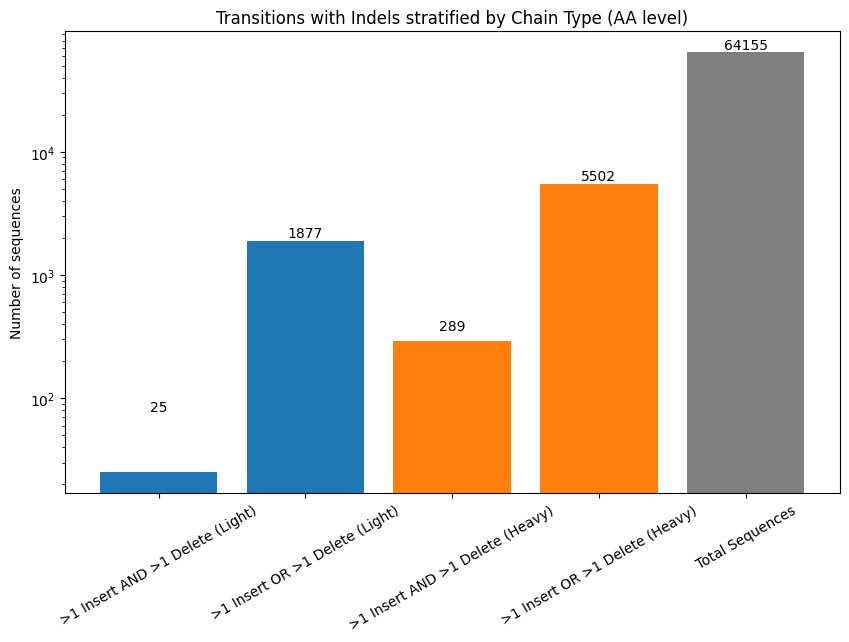

In [9]:
labels = [
    '>1 Insert AND >1 Delete (Light)', '>1 Insert OR >1 Delete (Light)',
    '>1 Insert AND >1 Delete (Heavy)', '>1 Insert OR >1 Delete (Heavy)', 'Total Sequences'
]

values = [
    ((indels["n_ins_light"] > 1) & (indels["n_del_light"] > 1)).sum(),
    ((indels["n_ins_light"] > 1) | (indels["n_del_light"] > 1)).sum(),
    ((indels["n_ins_heavy"] > 1) & (indels["n_del_heavy"] > 1)).sum(),
    ((indels["n_ins_heavy"] > 1) | (indels["n_del_heavy"] > 1)).sum(),
    len(indels)
]

colors = ['tab:blue', 'tab:blue', 'tab:orange', 'tab:orange', 'gray']

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, values, color=colors)
plt.ylabel('Number of sequences')
plt.title('Transitions with Indels stratified by Chain Type (AA level)')
for i, v in enumerate(values):
    plt.text(i, v + 50, str(v), ha='center', va='bottom')
plt.yscale('log')
plt.xticks(rotation=30)
plt.show()


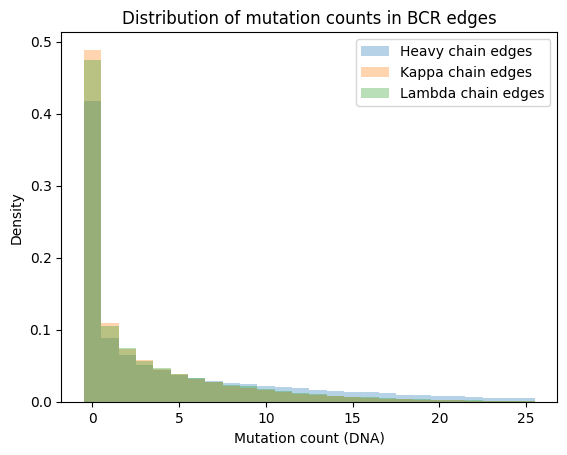

In [10]:
bins = np.linspace(-0.5, 25.5, 27)
plt.hist(heavy.n_mut, bins=bins, alpha=0.33, label='Heavy chain edges', density=True)
plt.hist(kappa.n_mut, bins=bins, alpha=0.33, label='Kappa chain edges', density=True)
plt.hist(lambd.n_mut, bins=bins, alpha=0.33, label='Lambda chain edges', density=True)
plt.legend()
plt.xlabel('Mutation count (DNA)')
plt.ylabel('Density')
plt.title('Distribution of mutation counts in BCR edges')
plt.show()

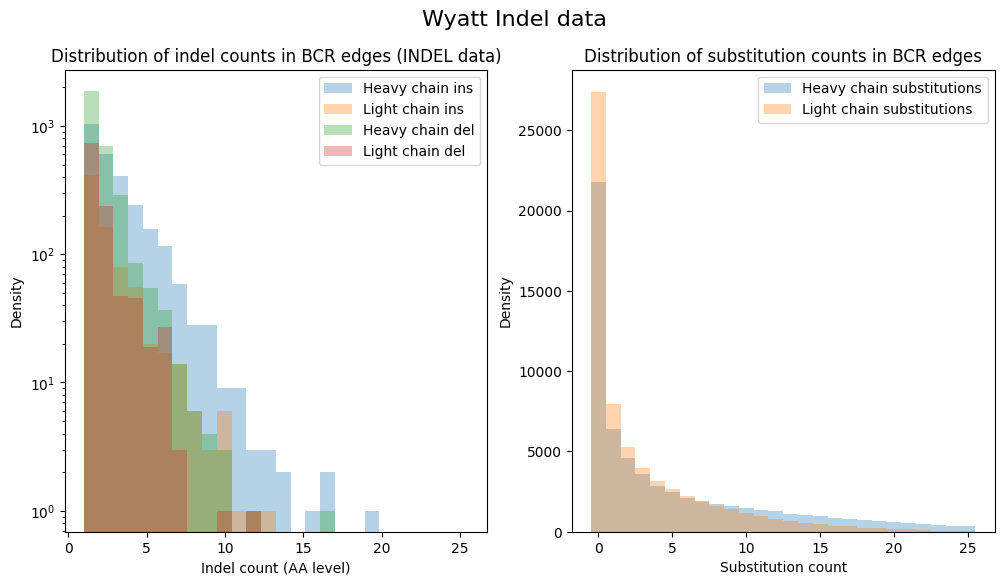

In [11]:
indel_bins = np.linspace(1, 25.5, 27)
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].hist(indels.n_ins_heavy // 3, bins=indel_bins, alpha=0.33, label="Heavy chain ins", density=False)
ax[0].hist(indels.n_ins_light // 3, bins=indel_bins, alpha=0.33, label="Light chain ins", density=False)
ax[0].hist(indels.n_del_heavy // 3, bins=indel_bins, alpha=0.33, label="Heavy chain del", density=False)
ax[0].hist(indels.n_del_light // 3, bins=indel_bins, alpha=0.33, label="Light chain del", density=False)
ax[0].legend()
ax[0].set_xlabel("Indel count (AA level)")
ax[0].set_yscale('log')
ax[0].set_ylabel("Density")
ax[0].set_title("Distribution of indel counts in BCR edges (INDEL data)")

ax[1].hist(indels.n_sub_heavy, bins=bins, alpha=0.33, label="Heavy chain substitutions", density=False)
ax[1].hist(indels.n_sub_light, bins=bins, alpha=0.33, label="Light chain substitutions", density=False)
ax[1].legend()
ax[1].set_xlabel("Substitution count")
ax[1].set_ylabel("Density")
ax[1].set_title("Distribution of substitution counts in BCR edges")

# Add overall title
plt.suptitle("Wyatt Indel data", fontsize=16)

plt.show()

In [11]:
merge_cols = ['sample_id', 'family', 'parent_name', 'child_name', 'edge_id']
keep_cols = ['parent', 'child', 'branch_length', 'depth', 'distance', 'v_gene', 'cdr1_codon_start', 
             'cdr1_codon_end', 'cdr2_codon_start', 'cdr2_codon_end', 'cdr3_codon_start', 'cdr3_codon_end',
             'parent_is_naive', 'child_is_leaf']
keep_cols = merge_cols + keep_cols

In [12]:
heavy_kappa = pd.merge(heavy[keep_cols], kappa[keep_cols], on=merge_cols, how='inner', suffixes=('_heavy', '_light'))
heavy_lambd = pd.merge(heavy[keep_cols], lambd[keep_cols], on=merge_cols, how='inner', suffixes=('_heavy', '_light'))
full_df = pd.concat([heavy_kappa, heavy_lambd], axis=0)
# full_df["n_mut"] = full_df.n_mut_heavy + full_df.n_mut_light

In [13]:
pd.unique(full_df.family[full_df.parent_name == 'naive']).shape

(67385,)

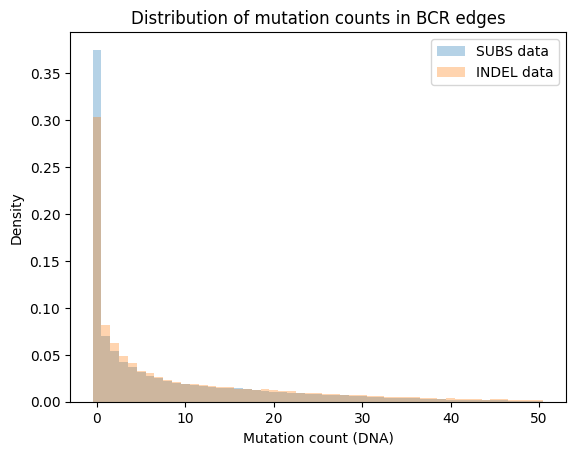

In [15]:
bins = np.linspace(-0.5, 50.5, 52)
plt.hist(full_df.n_mut, bins=bins, alpha=0.33, label='SUBS data', density=True)
plt.hist(indels.n_mut, bins=bins, alpha=0.33, label='INDEL data', density=True)
plt.legend()
plt.xlabel('Mutation count (DNA)')
plt.ylabel('Density')
plt.title('Distribution of mutation counts in BCR edges')
plt.show()

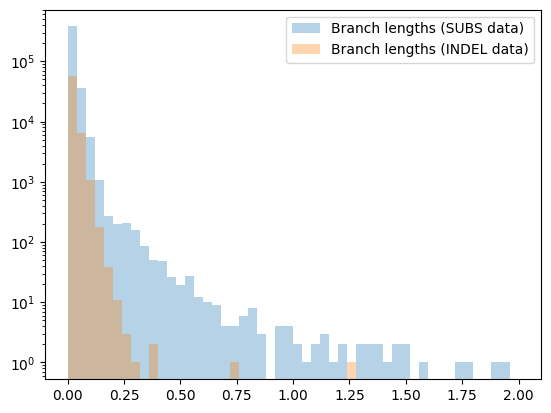

In [16]:
bins = np.linspace(0, 2, 51)
plt.hist(full_df.branch_length_heavy, bins=bins, alpha=0.33, label='Branch lengths (SUBS data)')
# plt.hist(full_df.branch_length_light, bins=bins, alpha=0.33, label='Light branch lengths (SUBS)')
plt.hist(indels.branch_length, bins=bins, alpha=0.33, label='Branch lengths (INDEL data)')
plt.legend()
plt.yscale('log')
plt.show()

In [17]:
spearmanr(full_df.branch_length_heavy, full_df.branch_length_light)

SignificanceResult(statistic=1.0, pvalue=0.0)

In [14]:
indels["parent_heavy_aa"] = indels["parent_heavy"].progress_apply(
    lambda x: str(Seq(remove_all_gaps(x)).translate())
)
indels['child_heavy_aa'] = indels['child_heavy'].progress_apply(
    lambda x: str(Seq(remove_all_gaps(x)).translate())
)
indels['parent_light_aa'] = indels['parent_light'].progress_apply(
    lambda x: str(Seq(remove_all_gaps(x)).translate())
)
indels['child_light_aa'] = indels['child_light'].progress_apply(
    lambda x: str(Seq(remove_all_gaps(x)).translate())
)
print(indels.shape)

  0%|          | 0/64155 [00:00<?, ?it/s]

100%|██████████| 64155/64155 [00:02<00:00, 26183.89it/s]

(64155, 35)


In [19]:
indels_unique = indels[(indels.parent_heavy_aa != indels.child_heavy_aa) | (indels.parent_light_aa != indels.child_light_aa)]
print(indels_unique.shape)

(43082, 35)


In [20]:
peint_df = full_df[[
    'edge_id', 'sample_id', 'family',
    'parent_heavy', 'parent_light',
    'child_heavy', 'child_light',
    'parent_name', 'child_name',
    'branch_length_heavy',
]]
peint_df['parent_heavy_aa'] = peint_df['parent_heavy'].progress_apply(lambda x: str(Seq(x).translate()))
peint_df['parent_light_aa'] = peint_df['parent_light'].progress_apply(lambda x: str(Seq(x).translate()))
peint_df['child_heavy_aa'] = peint_df['child_heavy'].progress_apply(lambda x: str(Seq(x).translate()))
peint_df['child_light_aa'] = peint_df['child_light'].progress_apply(lambda x: str(Seq(x).translate()))

peint_df = peint_df[(peint_df.parent_heavy_aa != peint_df.child_heavy_aa) | (peint_df.parent_light_aa != peint_df.child_light_aa)]
peint_df = peint_df.rename(columns={'branch_length_heavy':'branch_length'})
print(peint_df.shape)

100%|██████████| 422954/422954 [00:17<00:00, 24812.80it/s]
/tmp/ipykernel_1649181/3560556365.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  peint_df['parent_heavy_aa'] = peint_df['parent_heavy'].progress_apply(lambda x: str(Seq(x).translate()))
100%|██████████| 422954/422954 [00:15<00:00, 27187.61it/s]
/tmp/ipykernel_1649181/3560556365.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  peint_df['parent_light_aa'] = peint_df['parent_light'].progress_apply(lambda x: str(Seq(x).translate()))
100%|███████

(252723, 14)


In [21]:
peint_df = pd.concat([peint_df, indels_unique[peint_df.columns]], axis=0)
print(peint_df.shape)

(295805, 14)


In [22]:
bl_mean = peint_df["branch_length"].mean()
bl_std = peint_df["branch_length"].std()
peint_df["branch_length"] /= bl_mean

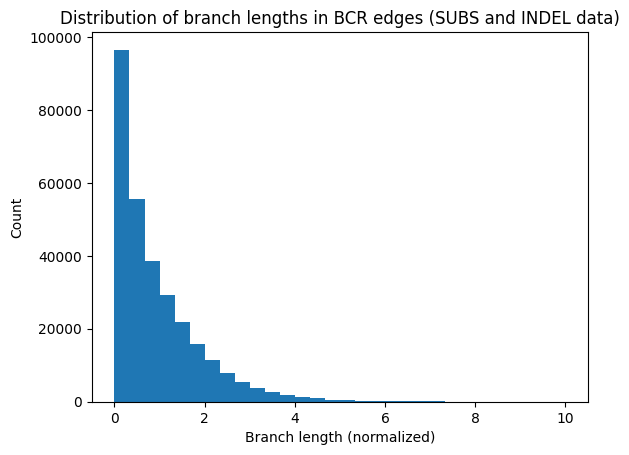

In [22]:
bins = np.linspace(0, 10, 31)
plt.hist(peint_df.branch_length, bins=bins)
plt.xlabel('Branch length (normalized)')
plt.ylabel('Count')
plt.title('Distribution of branch lengths in BCR edges (SUBS and INDEL data)')
plt.show()

In [23]:
# peint_indels = indels[peint_df.columns]
peint_indels = indels.copy()
peint_indels["original_branch_length"] = peint_indels["branch_length"]
peint_indels["branch_length"] /= bl_mean
print(peint_indels.shape)

(64155, 36)


In [24]:
df_edges = peint_indels[peint_indels["sample_id"] == "d4"]
df_edges = df_edges[
    (df_edges.parent_heavy_aa != df_edges.child_heavy_aa)
    | (df_edges.parent_light_aa != df_edges.child_light_aa)
]

for i in range(5):
    print(df_edges.iloc[i]["branch_length"], end=" ")

1.4165657723136795 3.928860376069267 0.2038963736381347 2.289122312441579 0.9847852163741001 

In [25]:
import os
def save_peint_df_to_txt(peint_df, base_path):
    for donor in pd.unique(peint_df.sample_id):
        subset = peint_df[peint_df.sample_id == donor]

        # parent = subset.parent_heavy_aa + ("G" * 10) + subset.parent_light_aa
        # child = subset.child_heavy_aa + ("G" * 10) + subset.child_light_aa
        parent = subset.parent_heavy_aa + "." + subset.parent_light_aa
        child = subset.child_heavy_aa + "." + subset.child_light_aa

        lines = parent + " " + child + " " + subset.branch_length.astype(str)
        os.makedirs(base_path + "edges_joint", exist_ok=True)
        outfile = base_path + "edges_joint/new_{0}.txt".format(donor)
        with open(outfile, "w") as f:
            f.write("{0} transitions\n".format(subset.shape[0]))
            f.write("\n".join(lines))

        # parent = subset.parent_heavy_aa
        # child = subset.child_heavy_aa
        # lines = parent + " " + child + " " + subset.branch_length.astype(str)
        # os.makedirs(base_path + "edges_heavy", exist_ok=True)
        # outfile = base_path + "edges_heavy/{0}.txt".format(donor)
        # with open(outfile, "w") as f:
        #     f.write("{0} transitions\n".format(subset.shape[0]))
        #     f.write("\n".join(lines))

        # parent = subset.parent_light_aa
        # child = subset.child_light_aa
        # lines = parent + " " + child + " " + subset.branch_length.astype(str)
        # os.makedirs(base_path + "edges_light", exist_ok=True)
        # outfile = base_path + "edges_light/{0}.txt".format(donor)
        # with open(outfile, "w") as f:
        #     f.write("{0} transitions\n".format(subset.shape[0]))
        #     f.write("\n".join(lines))

In [26]:
# save_peint_df_to_txt(peint_indels, base_path='wyatt/indels/')
save_peint_df_to_txt(peint_df, base_path="wyatt/all/")

In [25]:
save_dir = "/accounts/projects/yss/stephen.lu/protevo/plmr/data/"
peint_indels.to_csv(save_dir + "/wyatt/indels/full_df.csv.gz", compression="gzip", index=False)
# peint_df.to_csv("plmr/data/wyatt/all/peint_df.csv.gz", compression="gzip", index=False)
# peint_df.to_csv("plmr/data/wyatt/raw/peint_df.csv.gz", compression="gzip", index=False)